# Métodos de interpolación Función de Base Radial - RBF


Al comparar una RBF con IDW (que también es un interpolador exacto), IDW nunca predice valores por encima del valor máximo medido ni por debajo del valor mínimo medido, como se puede ver a continuación en la sección transversal de un transecto de datos de muestra.

Sin embargo, las RBF pueden predecir valores por encima del valor máximo medido y por debajo del valor mínimo medido, como en la sección transversal siguiente.

## Cuándo utilizar las funciones de base radial

* Las RBF se utilizan para generar superficies suaves a partir de un gran número de puntos de datos. Las funciones producen buenos resultados para superficies que varían levemente, como la elevación.

* Sin embargo, las técnicas no son adecuadas cuando se producen cambios grandes en los valores de la superficie en distancias cortas, o cuando sospecha que los datos de muestra son propensos a un error de medición o incertidumbre.

## Métodos de función
* ‘linear’ : -r

* ‘thin_plate_spline’ : r**2 * log(r)

* ‘cubic’ : r**3

* ‘quintic’ : -r**5

* ‘multiquadric’ : -sqrt(1 + r**2)

* ‘inverse_multiquadric’ : 1/sqrt(1 + r**2)

* ‘inverse_quadratic’ : 1/(1 + r**2)

* ‘gaussian’ : exp(-r**2)

## Buscar mejor smoothing y epsilon

In [16]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import os, glob

## Cargar datos vectoriales

In [15]:
shp_punto = glob.glob("Datos_transformados.shp")
shp_punto

['Datos_transformados.shp']

In [5]:
shp_parcela = glob.glob("zona.shp")
shp_parcela

['zona.shp']

In [6]:
# gdf_punto = gpd.read_file(shp_punto[0])
gdf_punto = gpd.read_file('Datos_transformados.shp')
gdf_parcela = gpd.read_file(shp_parcela[0])

In [7]:
gdf_punto.head(3)

,fid,ID,Arena,Arcilla,Limo,Textura,Ph,MO,N,P_ppm,...,AI,H,CICe,Bas_Camb,Ac_Camb,Sat_AI,X,Y,P_ppm_0.5,geometry
0,1,1,35,22,43,Franco,4.20,2.46,0.12,0.58,...,2.49,1.31,7.44,49,51,33,405495.08,554342.97,-0.476845,POINT (405495.08 554342.97)
1,2,2,47,20,33,Franco,4.07,2.28,0.11,2.28,...,3.07,1.53,6.97,34,66,44,405530.26,554341.22,1.019934,POINT (405530.26 554341.22)
2,3,3,23,30,47,Franco Arcillo Limoso,4.17,2.81,0.14,2.56,...,2.56,0.64,5.27,39,61,49,405585.65,554351.33,1.200000,POINT (405585.65 554351.33)


In [8]:
gdf_punto.columns

Index(['fid', 'ID', 'Arena', 'Arcilla', 'Limo', 'Textura', 'Ph', 'MO', 'N',
       'P_ppm', 'K_ppm', 'CIC', 'Ca', 'Mg', 'AI', 'H', 'CICe', 'Bas_Camb',
       'Ac_Camb', 'Sat_AI', 'X', 'Y', 'P_ppm_0.5', 'geometry'],
      dtype='object')

### Cargar el área limite del estudio

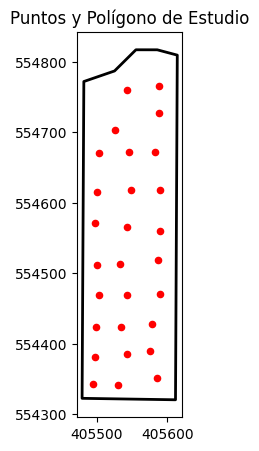

In [14]:
# Visualizar ambos datasets
fig, ax = plt.subplots(figsize=(7, 5))
gdf_parcela.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=2)
gdf_punto.plot(ax=ax, color="red", markersize=20)
plt.title("Puntos y Polígono de Estudio")
plt.show()

### Acceder a la informacion Este, Norte y Valores PH -->

In [82]:
x = gdf_punto.geometry.x.values
y = gdf_punto.geometry.y.values
coords = gdf_punto[["X", "Y"]].values
values = gdf_punto['Ph'].values

# Interpolacion Base Radial

In [85]:
from shapely.geometry import box
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import RBFInterpolator

In [84]:
# Lista de kernels a comparar
lista_kernels = ['linear', 'cubic', 'quintic', 'thin_plate_spline',
                  'multiquadric', 'inverse_multiquadric', 'gaussian']

In [86]:
lista_smoothing = [0.0, 0.01, 0.1]
lista_epsilon = [0.1, 1.0, 5.0]

In [87]:
from sklearn.model_selection import LeaveOneOut

In [88]:
# Preparar Leave-One-Out CV
loo = LeaveOneOut()

In [90]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [91]:
r_epsilon = []
r_smoothing = []
r_kernel = []
rmse_scores = []

In [92]:
for kernel in lista_kernels:
        for smoothing in lista_smoothing:
            for epsilon in lista_epsilon:
                y_true = []
                y_pred = []
                for train_idx, test_idx in loo.split(coords):
                    train_coords, test_coord = coords[train_idx], coords[test_idx].reshape(1, -1)
                    train_values, test_value = values[train_idx], values[test_idx][0]

                    # Crear el modelo
                    rbf = RBFInterpolator(train_coords, train_values, kernel=kernel,
                                      smoothing=smoothing, epsilon=epsilon)
                    Z_pred = rbf(test_coord)

                    y_true.append(test_value)
                    y_pred.append(Z_pred)

                # Calcular RMSE para este power
                rmse = mean_squared_error(y_true, y_pred)
                r_kernel.append(kernel)
                rmse_scores.append(rmse)
                r_smoothing.append(smoothing)
                r_epsilon.append(epsilon)

In [93]:
# Resultados
rmse_results = pd.DataFrame({"kernels": r_kernel,
                             "smoothing":r_smoothing,
                             "epsilon":r_epsilon,
                             "RMSE": rmse_scores})

In [94]:
# ordenar el DataFrame por RMSE para ver los mejores parámetros:
rmse_results.sort_values(by="RMSE", inplace=True)

In [95]:
rmse_results.head(5)

,kernels,smoothing,epsilon,RMSE
45,inverse_multiquadric,0.00,0.1,0.033254
48,inverse_multiquadric,0.01,0.1,0.033328
51,inverse_multiquadric,0.10,0.1,0.033987
6,linear,0.10,0.1,0.034965
3,linear,0.01,0.1,0.035261


In [96]:
best_kernels = rmse_results.loc[rmse_results["RMSE"].idxmin(), "kernels"]

In [97]:
print("Mejor Kernel es:", best_kernels)

Mejor Kernel es: inverse_multiquadric


## Determinar la interpolacion RBF mejor modelo

In [98]:
# Crear interpolador RBF con linear, defecto epsilon=1
rbf_metodo = RBFInterpolator(np.c_[x , y],
                             values,
                             kernel =best_kernels,
                             smoothing=0,
                             epsilon=0.1)

## Generar una cuadrícula dentro del polígono
Para asegurarnos de que la interpolación se realice solo dentro del polígono, generamos una cuadrícula regular de puntos y recortamos aquellos que caen fuera del polígono.

In [99]:
from shapely.geometry import Point
import numpy as np

In [100]:
parcela_bufer = gdf_parcela.buffer(30)

In [101]:
# Definir el límite del polígono
xmin, ymin, xmax, ymax = parcela_bufer.total_bounds

In [102]:
resolucion = 1

In [103]:
# Generar una cuadrícula regular
x_grid = np.arange(xmin, xmax, resolucion)
y_grid = np.arange(ymin, ymax, resolucion)
x_mesh, y_mesh = np.meshgrid(x_grid, y_grid)

In [104]:
# Convertir la cuadrícula en una lista de puntos
puntos_cuadricula = [Point(x, y) for x, y in zip(x_mesh.ravel(), y_mesh.ravel())]

In [105]:
# Crear un GeoDataFrame con los puntos de la cuadrícula
cuadricula_gdf = gpd.GeoDataFrame(geometry=puntos_cuadricula,crs="EPSG:32716")

In [106]:
# Recortar la cuadrícula con el polígono
cuadricula_recortada = cuadricula_gdf[cuadricula_gdf.intersects(parcela_bufer.union_all())]

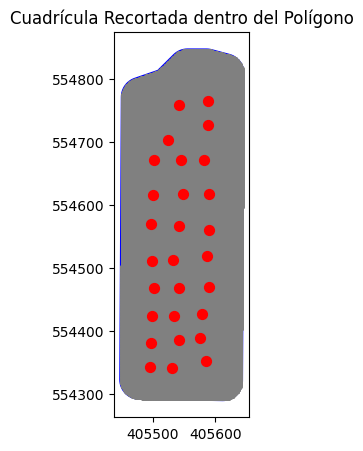

In [107]:
# Visualizar la cuadrícula recortada
fig, ax = plt.subplots(figsize=(7, 5))
parcela_bufer.plot(ax=ax, facecolor="none", edgecolor="blue", linewidth=2)
cuadricula_recortada.plot(ax=ax, color="gray", markersize=1)
gdf_punto.plot(ax=ax, color="red", markersize=50)
plt.title("Cuadrícula Recortada dentro del Polígono")
plt.show()

In [108]:
# === Extraer valores interpolados en cada celda ===
valores_metodo = []
for celda in cuadricula_recortada.geometry:
    centroide = celda.centroid
    valor_metodo = rbf_metodo([[centroide.x, centroide.y]])[0]
    # Agegar los valores a la lista
    valores_metodo.append(valor_metodo)

In [109]:
# Asignar los valores interpolados a la cuadrícula
cuadricula_recortada.loc[:, 'RBF_Met'] = np.round(valores_metodo,4)

/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [110]:
cuadricula_recortada.head()

,geometry,RBF_Met
294,POINT (405547.058 554291.398),4.1906
295,POINT (405548.058 554291.398),4.1906
296,POINT (405549.058 554291.398),4.1906
297,POINT (405550.058 554291.398),4.1906
298,POINT (405551.058 554291.398),4.1906


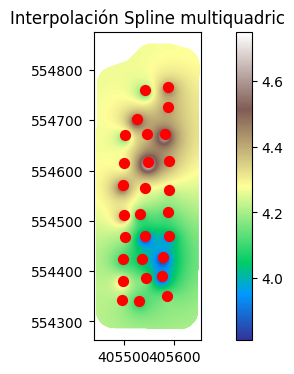

In [111]:
fig, ax = plt.subplots(figsize=(9, 4))
parcela_bufer.plot(ax=ax, facecolor="none", edgecolor="blue", linewidth=2)
cuadricula_recortada.plot(column='RBF_Met',
                          ax=ax, cmap='terrain', markersize=10,
                          legend=True)
gdf_punto.plot(ax=ax, color="red", markersize=50)
plt.title("Interpolación Spline multiquadric")
plt.show()

### Exportar en raster

In [112]:
!pip install rasterio
import rasterio
from rasterio.transform import from_origin
from rasterio.features import rasterize

In [113]:
cuadricula_recortada.columns

Index(['geometry', 'RBF_Met'], dtype='object')

In [114]:
# Definir resolución del raster
resolucion = 1  # Espaciado de la cuadrícula
xmin, ymin, xmax, ymax = parcela_bufer.total_bounds
ancho = int((xmax - xmin) / resolucion)
alto = int((ymax - ymin) / resolucion)

In [115]:
# Crear una transformación para el raster
transform = from_origin(xmin, ymax, resolucion, resolucion)

In [116]:
# Extraer geometrías y valores interpolados
geometrias_RBF_linear = [(geom, valor) for geom,
                         valor in zip(cuadricula_recortada.geometry,
                                      cuadricula_recortada['RBF_Met'])]

In [117]:
# Rasterizar los valores interpolados
raster_RBF_linear = rasterize(geometrias_RBF_linear,
                   out_shape=(alto, ancho),
                   transform=transform,
                   fill=np.nan,  # Valores fuera de la cuadrícula
                   all_touched=False,
                   dtype='float32')

In [118]:
# Guardar el raster RBF linear
with rasterio.open("interpolacion_RBF_" + best_kernels + ".tif", 'w',
                   driver='GTiff',
                   height=raster_RBF_linear.shape[0],
                   width=raster_RBF_linear.shape[1],
                   count=1,
                   dtype='float32',
                   crs=parcela_bufer.crs,
                   transform=transform,
                  ) as dst:
    dst.write(raster_RBF_linear, 1)

### Validación cruzada Leave-One-Out

In [119]:
import numpy as np
from sklearn.metrics import mean_squared_error

In [120]:
# === Inicialización de listas para almacenar resultados ===
errores_prediccion = []
valores_interpolados = []

In [121]:
puntos = np.array(gdf_punto[['X',"Y"]])

In [122]:
# === Validación cruzada Leave-One-Out ===
for i in range(len(puntos)):
    # Excluir el punto i
    puntos_entrenamiento = np.delete(puntos, i, axis=0)
    valores_entrenamiento = np.delete(values, i)
    # Crear el interpolador con los puntos restantes
    interpolador = RBFInterpolator(puntos_entrenamiento, valores_entrenamiento, kernel =best_kernels,
                             epsilon=0.1)
    # Predecir el valor en el punto excluido
    valor_interpolado = interpolador([puntos[i]])[0]
    # Calcular el error para este punto
    error = values[i] - valor_interpolado
    valores_interpolados.append(valor_interpolado)
    errores_prediccion.append(error)

In [123]:
# === Calcular métricas de evaluación ===
valores_interpolados = np.array(valores_interpolados)
errores_prediccion = np.array(errores_prediccion)
mse = mean_squared_error(values, valores_interpolados)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(errores_prediccion))

In [132]:
print(f"Resultados de Validación Cruzada Leave-One-Out:")
print(f" - MSE (Error cuadrático medio): {mse:.4f}")
print(f" - RMSE (Raíz del error cuadrático medio): {rmse:.4f}")
print(f" - MAE (Error absoluto medio): {mae:.4f}")

Resultados de Validación Cruzada Leave-One-Out:
 - MSE (Error cuadrático medio): 0.0333
 - RMSE (Raíz del error cuadrático medio): 0.1824
 - MAE (Error absoluto medio): 0.1494


In [125]:
 # Convertir resultados en DataFrame
validacion = pd.DataFrame({
    'Valor_Real': values,
    'Valor_Interpolado': valores_interpolados,
    'Error': errores_prediccion,
    'Error_Absoluto': np.abs(errores_prediccion)})

In [126]:
validacion.to_excel("Validacion_RBF.xlsx")